In [15]:
import math
import random
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn


In [16]:
# Physical, geometric, source, and output parameters shared with the FEM notebook.
from params import (
    A_stim,
    T,
    a1,
    a2,
    hole_r,
    hole_x,
    hole_y,
    r_value,
    s_stim,
    snapshot_times,
    source_amplitude,
    source_period,
    source_phase,
    source_spatial_width,
    source_time_width,
    source_x,
    source_y,
    x0,
    y0,
)


In [17]:
results_dir = Path("comparison_results")
results_dir.mkdir(exist_ok=True)

In [18]:
@dataclass(frozen=True)
class ModelSpec:
    hidden_layers: int
    hidden_width: int


class MonodomainPINN(nn.Module):
    """MLP approximation with an output transform enforcing u(x, y, 0)=u0."""

    def __init__(self, spec: ModelSpec) -> None:
        super().__init__()
        layers: list[nn.Module] = []
        input_width = 3
        for _ in range(spec.hidden_layers):
            linear = nn.Linear(input_width, spec.hidden_width)
            nn.init.xavier_normal_(linear.weight)
            nn.init.zeros_(linear.bias)
            layers.extend((linear, nn.Tanh()))
            input_width = spec.hidden_width
        output = nn.Linear(input_width, 1)
        nn.init.xavier_normal_(output.weight)
        nn.init.zeros_(output.bias)
        layers.append(output)
        self.network = nn.Sequential(*layers)

    def forward(self, points: Tensor) -> Tensor:
        x = points[:, 0:1]
        y = points[:, 1:2]
        t = points[:, 2:3]
        # x and y already lie in [-1, 1]; normalize time to the same interval.
        normalized = torch.cat((x, y, 2.0 * t / T - 1.0), dim=1)
        raw = self.network(normalized)

        # This transform is exactly u0 at t=0 while leaving the network free
        # to represent the solution for every t>0.
        reaction_decay = torch.exp(-r_value * t)
        return reaction_decay * initial_condition(x, y) + (1.0 - reaction_decay) * raw


## FEM-aligned anisotropic reaction-diffusion problem

The network approximates $u(x,y,t)$ on the unit disk with the circular hole

$$\Omega=\{(x,y):x^2+y^2<1\}\setminus
\{(x,y):(x-x_h)^2+(y-y_h)^2\leq r_h^2\}.$$

It solves the same continuous PDE as `FEM-code-new-simple.ipynb`:

$$u_t-\nabla\cdot(D\nabla u)+r u=F(x,y,t),\qquad
D=\operatorname{diag}(a_1,a_2),$$

with the Gaussian initial condition from `params.py` and homogeneous Neumann
conditions $(D\nabla u)\cdot n=0$ on both the outer circle and the hole. The
forcing is $F(x,y,t)=f(x,y)g(t)$, using the same spatial Gaussian and smooth
periodic Gaussian-like heartbeat as the FEM notebook.


In [19]:
def initial_condition(x: Tensor, y: Tensor) -> Tensor:
    radius_sq = (x - x0) ** 2 + (y - y0) ** 2
    return A_stim * torch.exp(-radius_sq / (2.0 * s_stim**2))


def diffusivity(x: Tensor, y: Tensor) -> Tensor:
    """Return the diagonal entries of the constant anisotropic tensor D."""
    return torch.cat((torch.full_like(x, a1), torch.full_like(y, a2)), dim=1)


def source_spatial_profile(x: Tensor, y: Tensor) -> Tensor:
    radius_sq = (x - source_x) ** 2 + (y - source_y) ** 2
    return source_amplitude * torch.exp(
        -radius_sq / (2.0 * source_spatial_width**2)
    )


def source_time_profile(t: Tensor) -> Tensor:
    phase_angle = math.pi * (t - source_phase) / source_period
    scaled_width = math.pi * source_time_width / source_period
    return torch.exp(-torch.sin(phase_angle).square() / (2.0 * scaled_width**2))


def source_term(x: Tensor, y: Tensor, t: Tensor) -> Tensor:
    return source_spatial_profile(x, y) * source_time_profile(t)


def _inside_domain(xy: Tensor) -> Tensor:
    inside_outer = xy[:, 0].square() + xy[:, 1].square() <= 1.0
    outside_hole = (
        (xy[:, 0] - hole_x).square() + (xy[:, 1] - hole_y).square()
        >= hole_r**2
    )
    return inside_outer & outside_hole


def sample_uniform_xy(count: int, device: torch.device, dtype: torch.dtype) -> Tensor:
    """Uniform area sampling in the perforated unit disk."""
    accepted: list[Tensor] = []
    remaining = count
    while remaining:
        candidate_count = max(2 * remaining, 16)
        radius = torch.sqrt(torch.rand((candidate_count, 1), device=device, dtype=dtype))
        angle = 2.0 * math.pi * torch.rand(
            (candidate_count, 1), device=device, dtype=dtype
        )
        candidates = torch.cat(
            (radius * torch.cos(angle), radius * torch.sin(angle)), dim=1
        )
        batch = candidates[_inside_domain(candidates)][:remaining]
        accepted.append(batch)
        remaining -= len(batch)
    return torch.cat(accepted, dim=0)


def sample_source_xy(count: int, device: torch.device, dtype: torch.dtype) -> Tensor:
    """Gaussian samples around the source, rejected against the geometry."""
    accepted: list[Tensor] = []
    remaining = count
    center = torch.tensor([[source_x, source_y]], device=device, dtype=dtype)
    while remaining:
        candidate_count = max(2 * remaining, 16)
        candidates = center + source_spatial_width * torch.randn(
            (candidate_count, 2), device=device, dtype=dtype
        )
        batch = candidates[_inside_domain(candidates)][:remaining]
        accepted.append(batch)
        remaining -= len(batch)
    return torch.cat(accepted, dim=0)


def sample_uniform_times(count: int, device: torch.device, dtype: torch.dtype) -> Tensor:
    return T * torch.rand((count, 1), device=device, dtype=dtype)


def pulse_centers(device: torch.device, dtype: torch.dtype) -> Tensor:
    first = math.ceil((0.0 - source_phase) / source_period)
    last = math.floor((T - source_phase) / source_period)
    indices = torch.arange(first, last + 1, device=device, dtype=dtype)
    return source_phase + source_period * indices


def sample_pulse_times(count: int, device: torch.device, dtype: torch.dtype) -> Tensor:
    """Truncated Gaussian samples around every source pulse in [0, T]."""
    centers = pulse_centers(device, dtype)
    accepted: list[Tensor] = []
    remaining = count
    while remaining:
        candidate_count = max(2 * remaining, 16)
        choices = torch.randint(len(centers), (candidate_count,), device=device)
        candidates = centers[choices, None] + source_time_width * torch.randn(
            (candidate_count, 1), device=device, dtype=dtype
        )
        batch = candidates[(candidates[:, 0] >= 0.0) & (candidates[:, 0] <= T)][:remaining]
        accepted.append(batch)
        remaining -= len(batch)
    return torch.cat(accepted, dim=0)


def sample_interior_components(
    count: int, device: torch.device, dtype: torch.dtype
) -> dict[str, Tensor]:
    """Return the 50/25/25 uniform, source, and joint source-pulse mixture."""
    if count <= 0:
        raise ValueError("count must be positive")
    uniform_count = count // 2
    source_count = count // 4
    pulse_count = count - uniform_count - source_count
    return {
        "uniform": torch.cat(
            (sample_uniform_xy(uniform_count, device, dtype),
             sample_uniform_times(uniform_count, device, dtype)), dim=1
        ),
        "source": torch.cat(
            (sample_source_xy(source_count, device, dtype),
             sample_uniform_times(source_count, device, dtype)), dim=1
        ),
        "pulse": torch.cat(
            (sample_source_xy(pulse_count, device, dtype),
             sample_pulse_times(pulse_count, device, dtype)), dim=1
        ),
    }


def sample_interior(count: int, device: torch.device, dtype: torch.dtype) -> Tensor:
    return torch.cat(tuple(sample_interior_components(count, device, dtype).values()))


def sample_boundary(
    count: int, device: torch.device, dtype: torch.dtype
) -> tuple[Tensor, Tensor]:
    """Sample both circles by perimeter and return points plus outward normals."""
    if count <= 0:
        raise ValueError("count must be positive")
    inner_count = int(round(count * hole_r / (1.0 + hole_r)))
    if count >= 2:
        inner_count = min(max(inner_count, 1), count - 1)
    outer_count = count - inner_count

    outer_angle = 2.0 * math.pi * torch.rand(
        (outer_count, 1), device=device, dtype=dtype
    )
    outer_direction = torch.cat((torch.cos(outer_angle), torch.sin(outer_angle)), dim=1)
    outer_xy = outer_direction
    outer_normals = outer_direction

    inner_angle = 2.0 * math.pi * torch.rand(
        (inner_count, 1), device=device, dtype=dtype
    )
    inner_direction = torch.cat((torch.cos(inner_angle), torch.sin(inner_angle)), dim=1)
    hole_center = torch.tensor([[hole_x, hole_y]], device=device, dtype=dtype)
    inner_xy = hole_center + hole_r * inner_direction
    inner_normals = -inner_direction

    xy = torch.cat((outer_xy, inner_xy), dim=0)
    normals = torch.cat((outer_normals, inner_normals), dim=0)
    points = torch.cat((xy, sample_uniform_times(count, device, dtype)), dim=1)
    permutation = torch.randperm(count, device=device)
    return points[permutation], normals[permutation]


In [20]:
def gradient(value: Tensor, points: Tensor, create_graph: bool = True) -> Tensor:
    return torch.autograd.grad(
        value,
        points,
        grad_outputs=torch.ones_like(value),
        create_graph=create_graph,
        retain_graph=True,
    )[0]


def pde_residual(model: MonodomainPINN, points: Tensor) -> Tensor:
    points = points.detach().requires_grad_(True)
    u = model(points)
    grad_u = gradient(u, points)
    u_x, u_y, u_t = grad_u[:, 0:1], grad_u[:, 1:2], grad_u[:, 2:3]
    a = diffusivity(points[:, 0:1], points[:, 1:2])
    a1_values, a2_values = a[:, 0:1], a[:, 1:2]

    flux_x, flux_y = a1_values * u_x, a2_values * u_y
    div_flux = (
        gradient(flux_x, points)[:, 0:1]
        + gradient(flux_y, points)[:, 1:2]
    )
    forcing = source_term(
        points[:, 0:1], points[:, 1:2], points[:, 2:3]
    )
    return u_t - div_flux + r_value * u - forcing


def boundary_flux(
    model: MonodomainPINN, points: Tensor, normals: Tensor
) -> Tensor:
    points = points.detach().requires_grad_(True)
    u = model(points)
    grad_u = gradient(u, points)
    a = diffusivity(points[:, 0:1], points[:, 1:2])
    a1_values, a2_values = a[:, 0:1], a[:, 1:2]
    return (
        a1_values * grad_u[:, 0:1] * normals[:, 0:1]
        + a2_values * grad_u[:, 1:2] * normals[:, 1:2]
    )


In [21]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

In [22]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")    

Using device: cuda


In [23]:
# Float64 is recommended for the second spatial derivatives. Set this to False
# for a short float32 comparison or when memory/runtime is limiting.
use_float64 = device.type != "mps"
dtype = torch.float64 if use_float64 else torch.float32
# Keep Adam's scalar bookkeeping state in float32 on PyTorch 2.1. The model
# and all collocation tensors are converted to `dtype` explicitly.
torch.set_default_dtype(torch.float32)
print(f"Training dtype: {dtype}; global default: {torch.get_default_dtype()}")


Training dtype: torch.float64; global default: torch.float32


In [24]:
set_seed(42)

In [25]:
hidden_layers       = 5
hidden_width        = 128
learning_rate       = 1.0e-3
epochs              = 12000
min_learning_rate   = 1.0e-4
#
interior_batch      = 8192
boundary_batch      = 512
validation_interior = 4096
validation_boundary = 512
#
boundary_weight     = 1.0
grad_clip           = 5.0
clip_warmup_epochs  = 500
validation_every    = 100
lr_patience_checks  = 10
early_stop_checks   = 25
validation_min_delta = 1.0e-4
log_every           = 100


In [26]:
spec = ModelSpec(hidden_layers, hidden_width)
model = MonodomainPINN(spec).to(device=device, dtype=dtype)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, foreach=False)
learning_rate_levels = (1.0e-3, 3.0e-4, min_learning_rate)
learning_rate_stage = 0


In [27]:
def validate_setup(
    model: MonodomainPINN,
    device: torch.device,
    dtype: torch.dtype,
    count: int = 120,
) -> float:
    """Check mixture ratios, pulse coverage, geometry, residuals, and autodiff."""
    components = sample_interior_components(count, device, dtype)
    interior = torch.cat(tuple(components.values()))
    boundary, normals = sample_boundary(count, device, dtype)
    assert {name: len(points) for name, points in components.items()} == {
        "uniform": count // 2,
        "source": count // 4,
        "pulse": count - count // 2 - count // 4,
    }
    assert interior.shape == (count, 3)
    assert boundary.shape == (count, 3) and normals.shape == (count, 2)

    tolerance = 100.0 * torch.finfo(dtype).eps
    outer_radius_sq = interior[:, 0].square() + interior[:, 1].square()
    hole_radius_sq = (
        (interior[:, 0] - hole_x).square()
        + (interior[:, 1] - hole_y).square()
    )
    assert torch.all(outer_radius_sq <= 1.0 + tolerance)
    assert torch.all(hole_radius_sq >= hole_r**2 - tolerance)

    boundary_outer_radius = torch.linalg.vector_norm(boundary[:, :2], dim=1)
    boundary_hole_radius = torch.linalg.vector_norm(
        boundary[:, :2] - torch.tensor([hole_x, hole_y], device=device, dtype=dtype),
        dim=1,
    )
    on_outer = torch.isclose(boundary_outer_radius, torch.ones_like(boundary_outer_radius),
                             atol=tolerance, rtol=tolerance)
    on_hole = torch.isclose(boundary_hole_radius, torch.full_like(boundary_hole_radius, hole_r),
                            atol=tolerance, rtol=tolerance)
    assert torch.all(on_outer | on_hole) and torch.any(on_outer) and torch.any(on_hole)
    assert torch.allclose(torch.linalg.vector_norm(normals, dim=1),
                          torch.ones(count, device=device, dtype=dtype),
                          atol=tolerance, rtol=tolerance)

    expected_normals = torch.empty_like(normals)
    expected_normals[on_outer] = boundary[on_outer, :2]
    hole_center = torch.tensor([hole_x, hole_y], device=device, dtype=dtype)
    expected_normals[on_hole] = (hole_center - boundary[on_hole, :2]) / hole_r
    assert torch.allclose(normals, expected_normals, atol=tolerance, rtol=tolerance)

    centers = pulse_centers(device, dtype)
    pulse_samples = sample_pulse_times(6000, device, dtype)
    nearest_centers = (pulse_samples - centers[None, :]).abs().argmin(dim=1)
    assert torch.all(torch.bincount(nearest_centers, minlength=len(centers)) > 0)

    source_peak = source_term(
        torch.full((1, 1), source_x, device=device, dtype=dtype),
        torch.full((1, 1), source_y, device=device, dtype=dtype),
        torch.full((1, 1), source_phase, device=device, dtype=dtype),
    )
    assert torch.allclose(source_peak, torch.full_like(source_peak, source_amplitude),
                          atol=tolerance, rtol=tolerance)

    residual = pde_residual(model, interior)
    flux = boundary_flux(model, boundary, normals)
    assert residual.shape == (count, 1) and torch.isfinite(residual).all()
    assert flux.shape == (count, 1) and torch.isfinite(flux).all()
    smoke_loss = residual.square().mean() + flux.square().mean()
    gradients = torch.autograd.grad(smoke_loss, tuple(model.parameters()))
    assert all(torch.isfinite(value).all() for value in gradients)

    initial_points = sample_interior(count, device, dtype)
    initial_points[:, 2] = 0.0
    with torch.inference_mode():
        initial_error = (
            model(initial_points)
            - initial_condition(initial_points[:, 0:1], initial_points[:, 1:2])
        ).abs().max().item()
    assert initial_error <= 10.0 * torch.finfo(dtype).eps
    return initial_error


initial_error = validate_setup(model, device, dtype)
print(f"parameters={sum(p.numel() for p in model.parameters()):,}")
print(f"maximum initial-condition error: {initial_error:.3e}")


parameters=66,689
maximum initial-condition error: 0.000e+00


In [28]:
# Recreate the optimizer whenever this training cell is run. This prevents stale
# Adam state after a notebook dtype/device change (for example float32 -> float64).
resolved_device = torch.empty(0, device=device).device
parameter_devices = {parameter.device for parameter in model.parameters()}
parameter_dtypes = {parameter.dtype for parameter in model.parameters()}
if parameter_devices != {resolved_device} or parameter_dtypes != {dtype}:
    raise RuntimeError(
        f"Model parameters are on {parameter_devices} with {parameter_dtypes}; "
        f"expected resolved device={resolved_device} (configured as {device}), "
        f"dtype={dtype}. Re-run the model setup cell."
    )
torch.set_default_dtype(torch.float32)
optimizer = torch.optim.Adam(
    model.parameters(), lr=learning_rate_levels[0], foreach=False
)
learning_rate_stage = 0

# Fixed, stratified validation points make plateau detection independent of
# the fresh Monte Carlo sample used by each training epoch.
validation_components = sample_interior_components(validation_interior, device, dtype)
validation_points = torch.cat(tuple(validation_components.values()))
validation_boundary_points, validation_normals = sample_boundary(
    validation_boundary, device, dtype
)


def evaluate_residual_groups(
    model: MonodomainPINN,
    components: dict[str, Tensor],
    boundary_points: Tensor,
    normals: Tensor,
) -> dict[str, float]:
    model.eval()
    values = {
        f"{name}_pde_loss": float(pde_residual(model, points).square().mean().detach().cpu())
        for name, points in components.items()
    }
    values["boundary_loss"] = float(
        boundary_flux(model, boundary_points, normals).square().mean().detach().cpu()
    )
    counts = {name: len(points) for name, points in components.items()}
    values["pde_loss"] = sum(
        counts[name] * values[f"{name}_pde_loss"] for name in components
    ) / sum(counts.values())
    values["total_loss"] = values["pde_loss"] + boundary_weight * values["boundary_loss"]
    return values


history: list[dict[str, float]] = []
best_validation_loss = math.inf
best_epoch = 0
best_losses: dict[str, float] = {}
best_state: dict[str, Tensor] | None = None
checks_without_improvement = 0

for epoch in range(1, epochs + 1):
    model.train()
    training_components = sample_interior_components(interior_batch, device, dtype)
    interior = torch.cat(tuple(training_components.values()))
    boundary, boundary_normals = sample_boundary(boundary_batch, device, dtype)
    residual = pde_residual(model, interior)
    flux = boundary_flux(model, boundary, boundary_normals)
    pde_loss = residual.square().mean()
    boundary_loss = flux.square().mean()
    total_loss = pde_loss + boundary_weight * boundary_loss

    if not torch.isfinite(total_loss):
        raise RuntimeError(f"Non-finite loss at epoch {epoch}")
    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    if epoch == 1:
        gradient_devices = {
            parameter.grad.device
            for parameter in model.parameters()
            if parameter.grad is not None
        }
        gradient_dtypes = {
            parameter.grad.dtype
            for parameter in model.parameters()
            if parameter.grad is not None
        }
        if gradient_devices != {resolved_device} or gradient_dtypes != {dtype}:
            raise RuntimeError(
                f"Gradients are on {gradient_devices} with {gradient_dtypes}; "
                f"expected device={resolved_device}, dtype={dtype}."
            )
    if epoch <= clip_warmup_epochs:
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    else:
        gradient_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), math.inf)
    if not torch.isfinite(gradient_norm):
        raise RuntimeError(f"Non-finite gradient at epoch {epoch}")
    optimizer.step()

    row = {
        "epoch": epoch,
        "total_loss": float(total_loss.detach().cpu()),
        "pde_loss": float(pde_loss.detach().cpu()),
        "boundary_loss": float(boundary_loss.detach().cpu()),
        "learning_rate": optimizer.param_groups[0]["lr"],
        "gradient_norm": float(gradient_norm.detach().cpu()),
    }

    should_validate = epoch == 1 or epoch % validation_every == 0 or epoch == epochs
    if should_validate:
        validation = evaluate_residual_groups(
            model, validation_components, validation_boundary_points, validation_normals
        )
        row.update({f"validation_{key}": value for key, value in validation.items()})
        improved = validation["total_loss"] < best_validation_loss * (1.0 - validation_min_delta)
        if improved:
            best_validation_loss = validation["total_loss"]
            best_epoch = epoch
            best_losses = validation.copy()
            best_state = {
                name: value.detach().cpu().clone()
                for name, value in model.state_dict().items()
            }
            checks_without_improvement = 0
        else:
            checks_without_improvement += 1

        if checks_without_improvement >= lr_patience_checks and learning_rate_stage < 2:
            learning_rate_stage += 1
            new_lr = learning_rate_levels[learning_rate_stage]
            for group in optimizer.param_groups:
                group["lr"] = new_lr
            checks_without_improvement = 0
            print(f"Validation plateau: reducing learning rate to {new_lr:.1e}")
        elif learning_rate_stage == 2 and checks_without_improvement >= early_stop_checks:
            history.append(row)
            print(f"Early stopping at epoch {epoch}; best validation epoch was {best_epoch}")
            break

    history.append(row)
    if epoch == 1 or epoch % log_every == 0 or epoch == epochs:
        validation_text = ""
        if should_validate:
            validation_text = (
                f"  val={validation['total_loss']:.4e} "
                f"[uniform={validation['uniform_pde_loss']:.2e}, "
                f"source={validation['source_pde_loss']:.2e}, "
                f"pulse={validation['pulse_pde_loss']:.2e}, "
                f"boundary={validation['boundary_loss']:.2e}]"
            )
        print(
            f"epoch {epoch:6d}/{epochs}  train={row['total_loss']:.4e}  "
            f"pde={row['pde_loss']:.4e}  boundary={row['boundary_loss']:.4e}  "
            f"grad={row['gradient_norm']:.2e}  lr={row['learning_rate']:.2e}"
            f"{validation_text}"
        )

if best_state is None:
    raise RuntimeError("Training finished without a finite validation checkpoint")
print(f"Best fixed-validation loss {best_validation_loss:.4e} at epoch {best_epoch}")


epoch      1/12000  train=7.7116e-02  pde=7.3610e-02  boundary=3.5061e-03  grad=1.26e+00  lr=1.00e-03  val=1.6260e-01 [uniform=1.38e-01, source=1.79e-01, pulse=1.56e-01, boundary=9.97e-03]
epoch    100/12000  train=3.6462e-02  pde=3.5848e-02  boundary=6.1363e-04  grad=2.08e-01  lr=1.00e-03  val=3.5903e-02 [uniform=6.60e-03, source=3.36e-02, pulse=9.45e-02, boundary=5.69e-04]
epoch    200/12000  train=3.2444e-02  pde=3.2167e-02  boundary=2.7633e-04  grad=3.60e-02  lr=1.00e-03  val=3.1850e-02 [uniform=4.36e-03, source=4.58e-02, pulse=7.16e-02, boundary=3.05e-04]
epoch    300/12000  train=3.0826e-02  pde=3.0748e-02  boundary=7.7713e-05  grad=1.77e-01  lr=1.00e-03  val=3.0462e-02 [uniform=3.24e-03, source=5.30e-02, pulse=6.17e-02, boundary=1.78e-04]
epoch    400/12000  train=3.1260e-02  pde=3.1157e-02  boundary=1.0318e-04  grad=1.52e-01  lr=1.00e-03  val=2.9851e-02 [uniform=3.37e-03, source=4.56e-02, pulse=6.66e-02, boundary=9.95e-05]
epoch    500/12000  train=2.9731e-02  pde=2.9606e-02  b

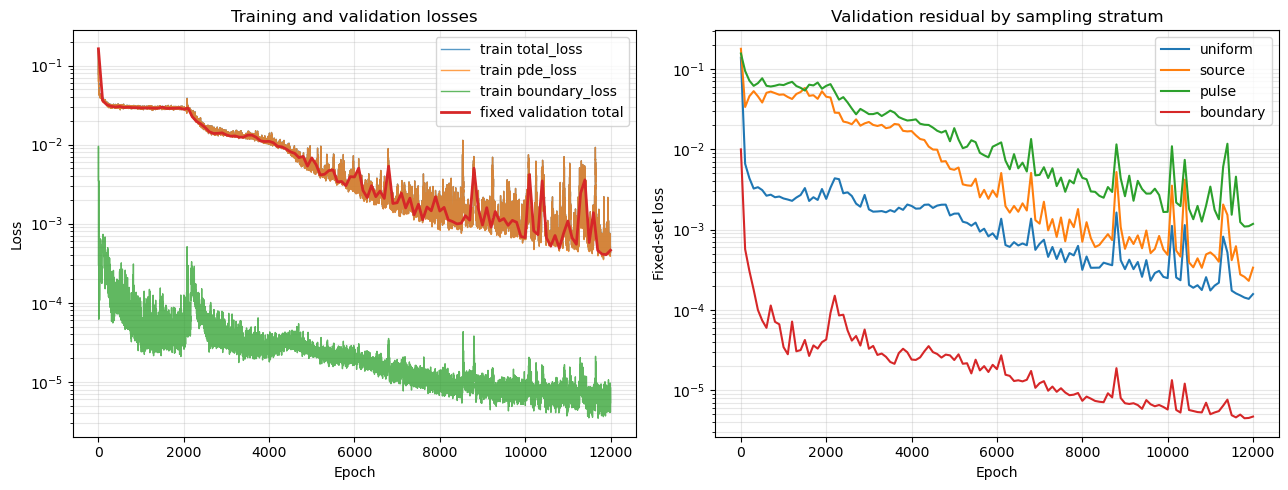

In [29]:
epochs_history = [row["epoch"] for row in history]
validation_rows = [row for row in history if "validation_total_loss" in row]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for loss_name in ("total_loss", "pde_loss", "boundary_loss"):
    axes[0].plot(epochs_history, [row[loss_name] for row in history],
                 label=f"train {loss_name}", linewidth=1.0, alpha=0.75)
axes[0].plot([row["epoch"] for row in validation_rows],
             [row["validation_total_loss"] for row in validation_rows],
             label="fixed validation total", linewidth=2.0)
axes[0].set(xlabel="Epoch", ylabel="Loss", yscale="log", title="Training and validation losses")
axes[0].grid(True, which="both", alpha=0.3)
axes[0].legend()

for group in ("uniform", "source", "pulse"):
    axes[1].plot([row["epoch"] for row in validation_rows],
                 [row[f"validation_{group}_pde_loss"] for row in validation_rows],
                 label=group, linewidth=1.5)
axes[1].plot([row["epoch"] for row in validation_rows],
             [row["validation_boundary_loss"] for row in validation_rows],
             label="boundary", linewidth=1.5)
axes[1].set(xlabel="Epoch", ylabel="Fixed-set loss", yscale="log",
            title="Validation residual by sampling stratum")
axes[1].grid(True, which="both", alpha=0.3)
axes[1].legend()
fig.tight_layout()


In [30]:
final_losses = {
    "last_training_total": history[-1]["total_loss"],
    "best_validation_total": best_validation_loss,
    "best_epoch": best_epoch,
    **{f"best_validation_{key}": value for key, value in best_losses.items()},
}
final_losses


{'last_training_total': 0.00046533808104421977,
 'best_validation_total': 0.00040600699156254284,
 'best_epoch': 11900,
 'best_validation_uniform_pde_loss': 0.00013699916705398412,
 'best_validation_source_pde_loss': 0.00022974319093941415,
 'best_validation_pulse_pde_loss': 0.0011022927949328426,
 'best_validation_boundary_loss': 4.498411567486626e-06,
 'best_validation_pde_loss': 0.00040150857999505623,
 'best_validation_total_loss': 0.00040600699156254284}

In [31]:
results_dir = Path("comparison_results")
points_xy = np.atleast_2d(
    np.loadtxt(results_dir / "comparison_points.txt")
)

In [32]:
# Always evaluate and export the checkpoint selected on the fixed validation set.
model.load_state_dict(best_state)
print(f"Restored best model from epoch {best_epoch}")


Restored best model from epoch 11900


In [33]:
snapshot_values = np.empty(
    (len(snapshot_times), len(points_xy)),
    dtype=np.float64,
)

In [34]:
was_training = model.training
model.eval()

MonodomainPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [35]:
with torch.inference_mode():
    for i, time in enumerate(snapshot_times):
        # PINN inputs have columns (x, y, t)
        points_xyt = np.column_stack((
            points_xy,
            np.full(len(points_xy), time),
        ))

        inputs = torch.as_tensor(
            points_xyt,
            device=device,
            dtype=dtype,
        )

        snapshot_values[i] = (
            model(inputs)
            .squeeze(-1)
            .cpu()
            .numpy()
        )

model.train(was_training)

MonodomainPINN(
  (network): Sequential(
    (0): Linear(in_features=3, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=1, bias=True)
  )
)

t=0.00: relative L2=0.000e+00, source-region relative L2=0.000e+00
t=1.00: relative L2=4.918e-01, source-region relative L2=2.155e-01
t=2.00: relative L2=5.072e-01, source-region relative L2=2.290e-01
t=3.00: relative L2=7.884e-01, source-region relative L2=3.305e-01
t=4.00: relative L2=1.704e-01, source-region relative L2=1.232e-01
t=5.00: relative L2=2.566e-01, source-region relative L2=1.083e-01


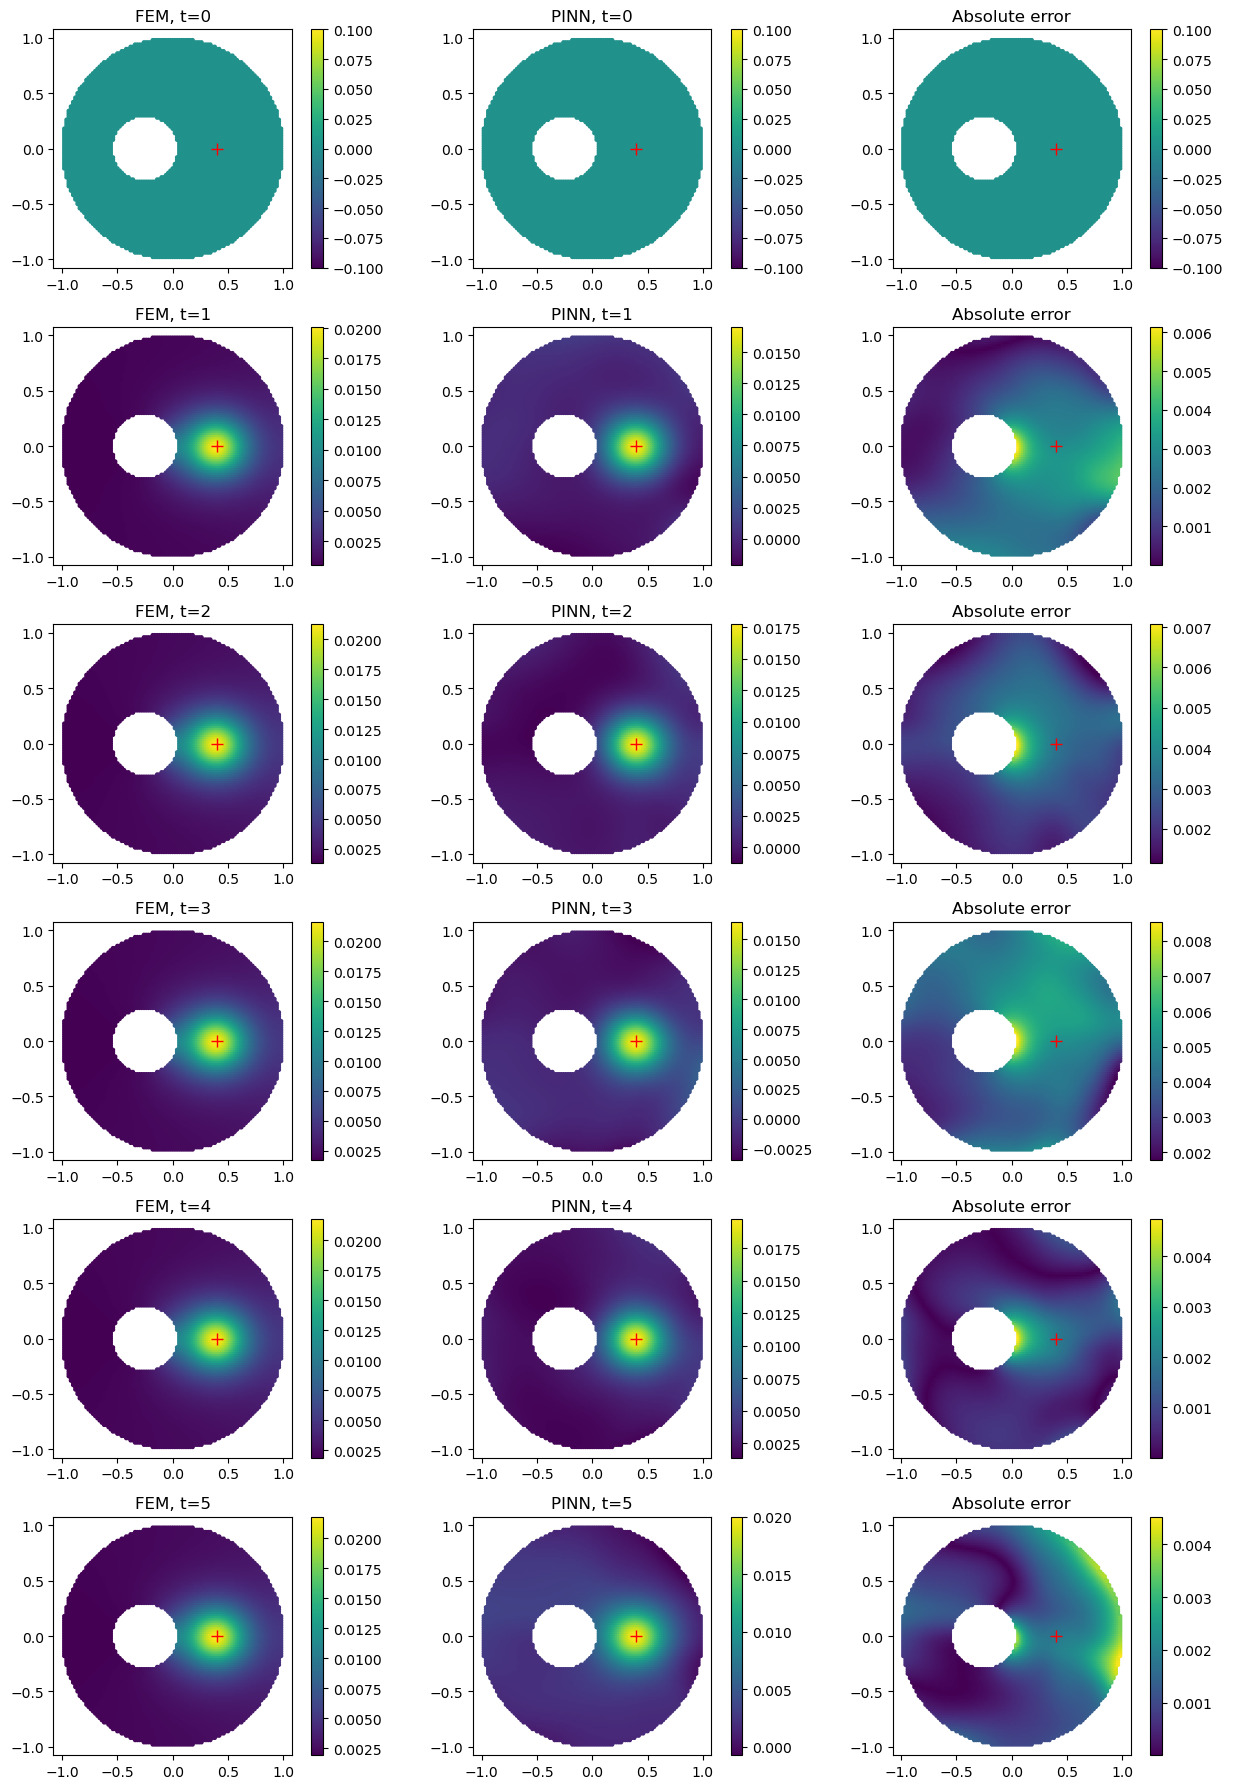

In [36]:
fem_file = results_dir / "fem_comparison_snapshots.npz"
if fem_file.exists():
    fem_data = np.load(fem_file)
    fem_points = fem_data["points"]
    fem_times = fem_data["times"]
    fem_values = fem_data["u"]
    if not (np.allclose(points_xy, fem_points) and np.allclose(snapshot_times, fem_times)):
        raise ValueError("FEM and PINN snapshot coordinates/times do not match")

    source_radius = np.linalg.norm(
        points_xy - np.array([source_x, source_y]), axis=1
    )
    source_mask = source_radius <= 2.0 * source_spatial_width

    def relative_l2(prediction: np.ndarray, reference: np.ndarray) -> float:
        denominator = np.linalg.norm(reference)
        return float(np.linalg.norm(prediction - reference) / max(denominator, 1.0e-14))

    fem_errors = []
    for i, time in enumerate(snapshot_times):
        fem_errors.append({
            "time": float(time),
            "relative_l2": relative_l2(snapshot_values[i], fem_values[i]),
            "source_relative_l2": relative_l2(
                snapshot_values[i, source_mask], fem_values[i, source_mask]
            ),
        })
    for row in fem_errors:
        print(
            f"t={row['time']:.2f}: relative L2={row['relative_l2']:.3e}, "
            f"source-region relative L2={row['source_relative_l2']:.3e}"
        )

    fig, axes = plt.subplots(len(snapshot_times), 3, figsize=(13, 3 * len(snapshot_times)),
                             squeeze=False)
    for i, time in enumerate(snapshot_times):
        fields = (fem_values[i], snapshot_values[i], np.abs(snapshot_values[i] - fem_values[i]))
        titles = (f"FEM, t={time:g}", f"PINN, t={time:g}", "Absolute error")
        for axis, field, title in zip(axes[i], fields, titles):
            artist = axis.scatter(points_xy[:, 0], points_xy[:, 1], c=field, s=5, cmap="viridis")
            axis.plot(source_x, source_y, "r+", markersize=8)
            axis.set_aspect("equal")
            axis.set_title(title)
            fig.colorbar(artist, ax=axis, fraction=0.046)
    fig.tight_layout()
else:
    print(f"Skipping FEM error diagnostics because {fem_file} was not found")


In [37]:
output_file = results_dir / "pinn_comparison_snapshots.npz"

np.savez_compressed(
    output_file,
    points=points_xy,             # (n_points, 2)
    times=snapshot_times,         # (n_times,)
    u=snapshot_values,            # (n_times, n_points)
)

print(f"Saved PINN results to {output_file}")

Saved PINN results to comparison_results/pinn_comparison_snapshots.npz
